# E-Commerce Sales & Profit Analysis

#### INTRODUCTION
In this notebook, we explore E-Commerce Sales & Profit Analysis dataset to understand patterns and trends in the market. The goal of this analysis is to explore the dataset, clean the data, visualize different aspects of the sales and find out insights.

##### Objectives
* Understand the structure of the dataset
* Perform basic data cleaning
* Which category generates highest profit?
* Which region needs improvement?
* Are high sales always profitable?
* Which products should company promote?

#### Libraries Used
* Pandas
* numpy
* matplotlib
* seaborn

#### Importing Libraries

In [1]:
%pip install seaborn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### Importing dataset


In [2]:
df = pd.read_csv("sales_data.csv")
df.head()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28


In [3]:
import os
print(os.getcwd())

/drive/notebooks/Projects/Sales


#### Exploring the basic datas and Understanding the Structure

In [4]:
df.describe()

,Quantity,Sales,Profit
count,3500.000000,3500.000000,3500.000000
mean,4.931714,3047.966000,527.047203
std,2.575895,2440.213237,504.139732
min,1.000000,51.000000,6.970000
25%,3.000000,1049.500000,158.695000
50%,5.000000,2350.500000,361.070000
75%,7.000000,4537.000000,729.125000
max,9.000000,10782.000000,2946.930000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3500 non-null   object 
 1   Product Name  3500 non-null   object 
 2   Category      3500 non-null   object 
 3   Region        3500 non-null   object 
 4   Quantity      3500 non-null   int64  
 5   Sales         3500 non-null   int64  
 6   Profit        3500 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 136.8+ KB


In [6]:
df.shape

(3500, 7)

In [7]:
df.isnull()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
3495,False,False,False,False,False,False,False
3496,False,False,False,False,False,False,False
3497,False,False,False,False,False,False,False
3498,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

Order Date      0
Product Name    0
Category        0
Region          0
Quantity        0
Sales           0
Profit          0
dtype: int64

#### Insight
There is no null Value in the data



To convert 'Order Date' String column into 'Order Date' Date object column.

In [9]:
pd.to_datetime(df['Order Date'])

0      2024-12-31
1      2022-11-27
2      2022-05-11
3      2024-03-16
4      2022-09-10
          ...    
3495   2023-02-15
3496   2022-09-18
3497   2022-04-12
3498   2022-01-18
3499   2024-11-01
Name: Order Date, Length: 3500, dtype: datetime64[ns]

### To findout which category generates highest Profit

In [10]:
df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

Category
Electronics    923185.59
Accessories    736084.74
Office         185394.88
Name: Profit, dtype: float64

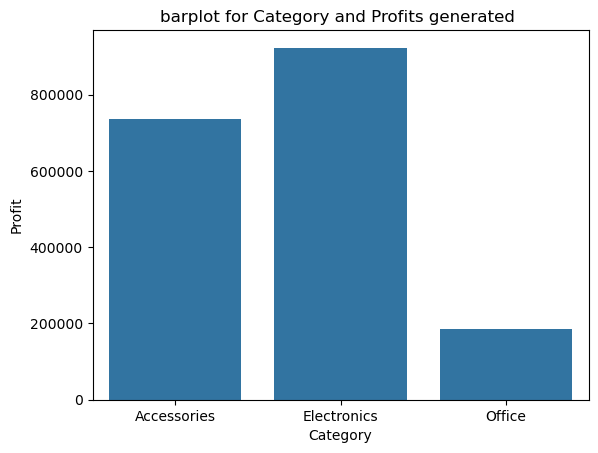

In [12]:
profit_cat = df.groupby('Category')['Profit'].sum().reset_index()
sns.barplot(profit_cat,x='Category',y='Profit')
plt.title("barplot for Category and Profits generated ")
plt.show()

### Insight
Based on the dataset, we analysed that Products from the category Electronics generates highest Profit.

### To find out which region needs improvement

To findout which region needs improvement, we can analyse Sales and Profit of each region.

In [23]:
df.groupby('Region')['Sales'].sum().sort_values()

Region
North    2488773
South    2659548
East     2675110
West     2844450
Name: Sales, dtype: int64

In [40]:
df.groupby('Region')[['Sales','Profit','Quantity']].sum().sort_values(['Sales','Profit','Quantity'])

,Sales,Profit,Quantity
Region,,,
North,2488773,426314.75,4106
South,2659548,458103.27,4361
East,2675110,464888.46,4306
West,2844450,495358.73,4488


### Insight
From these we can see that North Region has the lowest Sales and Profit indicating weak market penetration and lower demand compared to other regions.

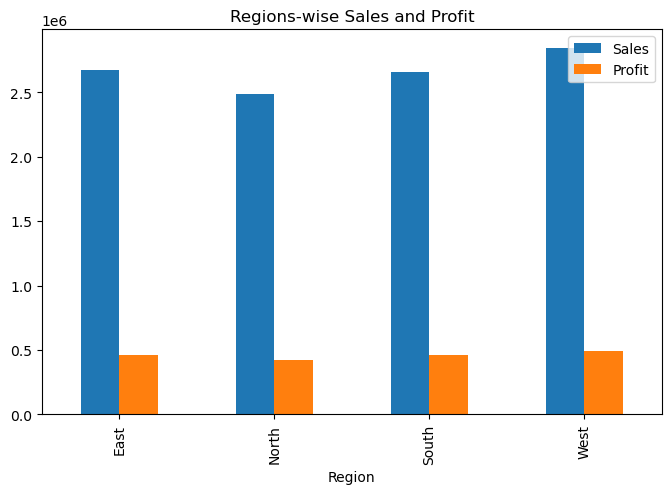

In [42]:
region_data = df.groupby('Region')[['Sales','Profit']].sum()
region_data.plot(kind='bar',figsize=(8,5))
plt.title("Regions-wise Sales and Profit")
plt.show()

### Are high Sales always Profitable?
To find out weather high sales are always profitable, we can compare sales and profit columns. We can use Scatterplot to visually do this.

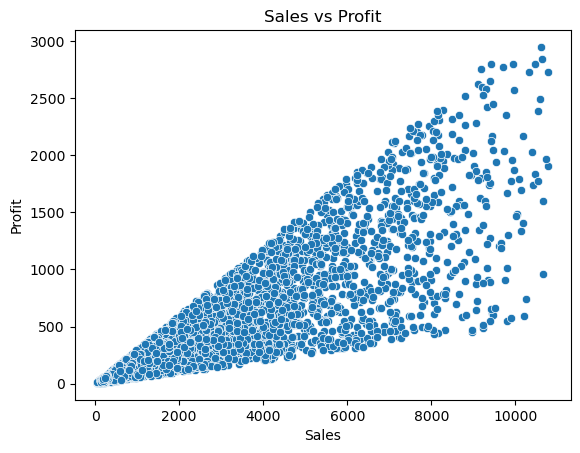

In [48]:
sns.scatterplot(x='Sales', y='Profit', data=df)
plt.title("Sales vs Profit")
plt.show()

### Insight
Here we can see that all profits are greater than 0, hence we can say that high sales are always high profitable

### Which products should company promote?


In [54]:
product_data = df.groupby('Product Name')[['Sales','Profit','Quantity']].sum()
product_data

,Sales,Profit,Quantity
Product Name,,,
Camera,1177381,207630.99,1795
Headphones,988638,172478.20,1604
Keyboard,1024507,175814.68,1684
Laptop,1005873,185756.81,1658
Monitor,1160048,202028.17,1876
Mouse,1074398,185763.69,1753
Printer,1094216,185394.88,1734
Smartphone,1069681,183296.97,1617
Smartwatch,1049211,178995.81,1807


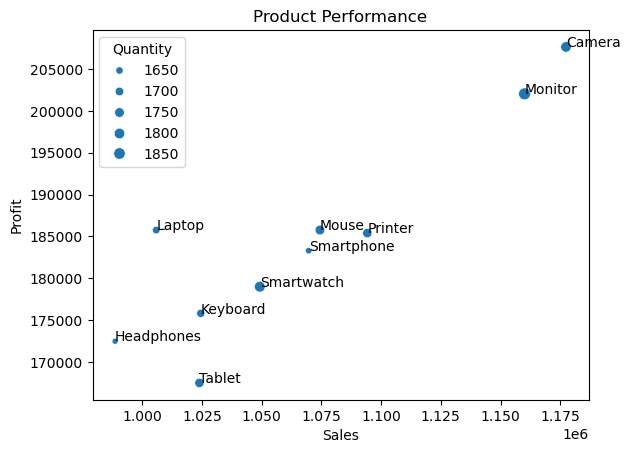

In [60]:
sns.scatterplot(x='Sales',y='Profit',size='Quantity',data=product_data)
for i in range(len(product_data)):
    plt.text(product_data['Sales'].iloc[i],
             product_data['Profit'].iloc[i],
             product_data.index[i])  # product name
plt.title("Product Performance")
plt.show()

### Ins